In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

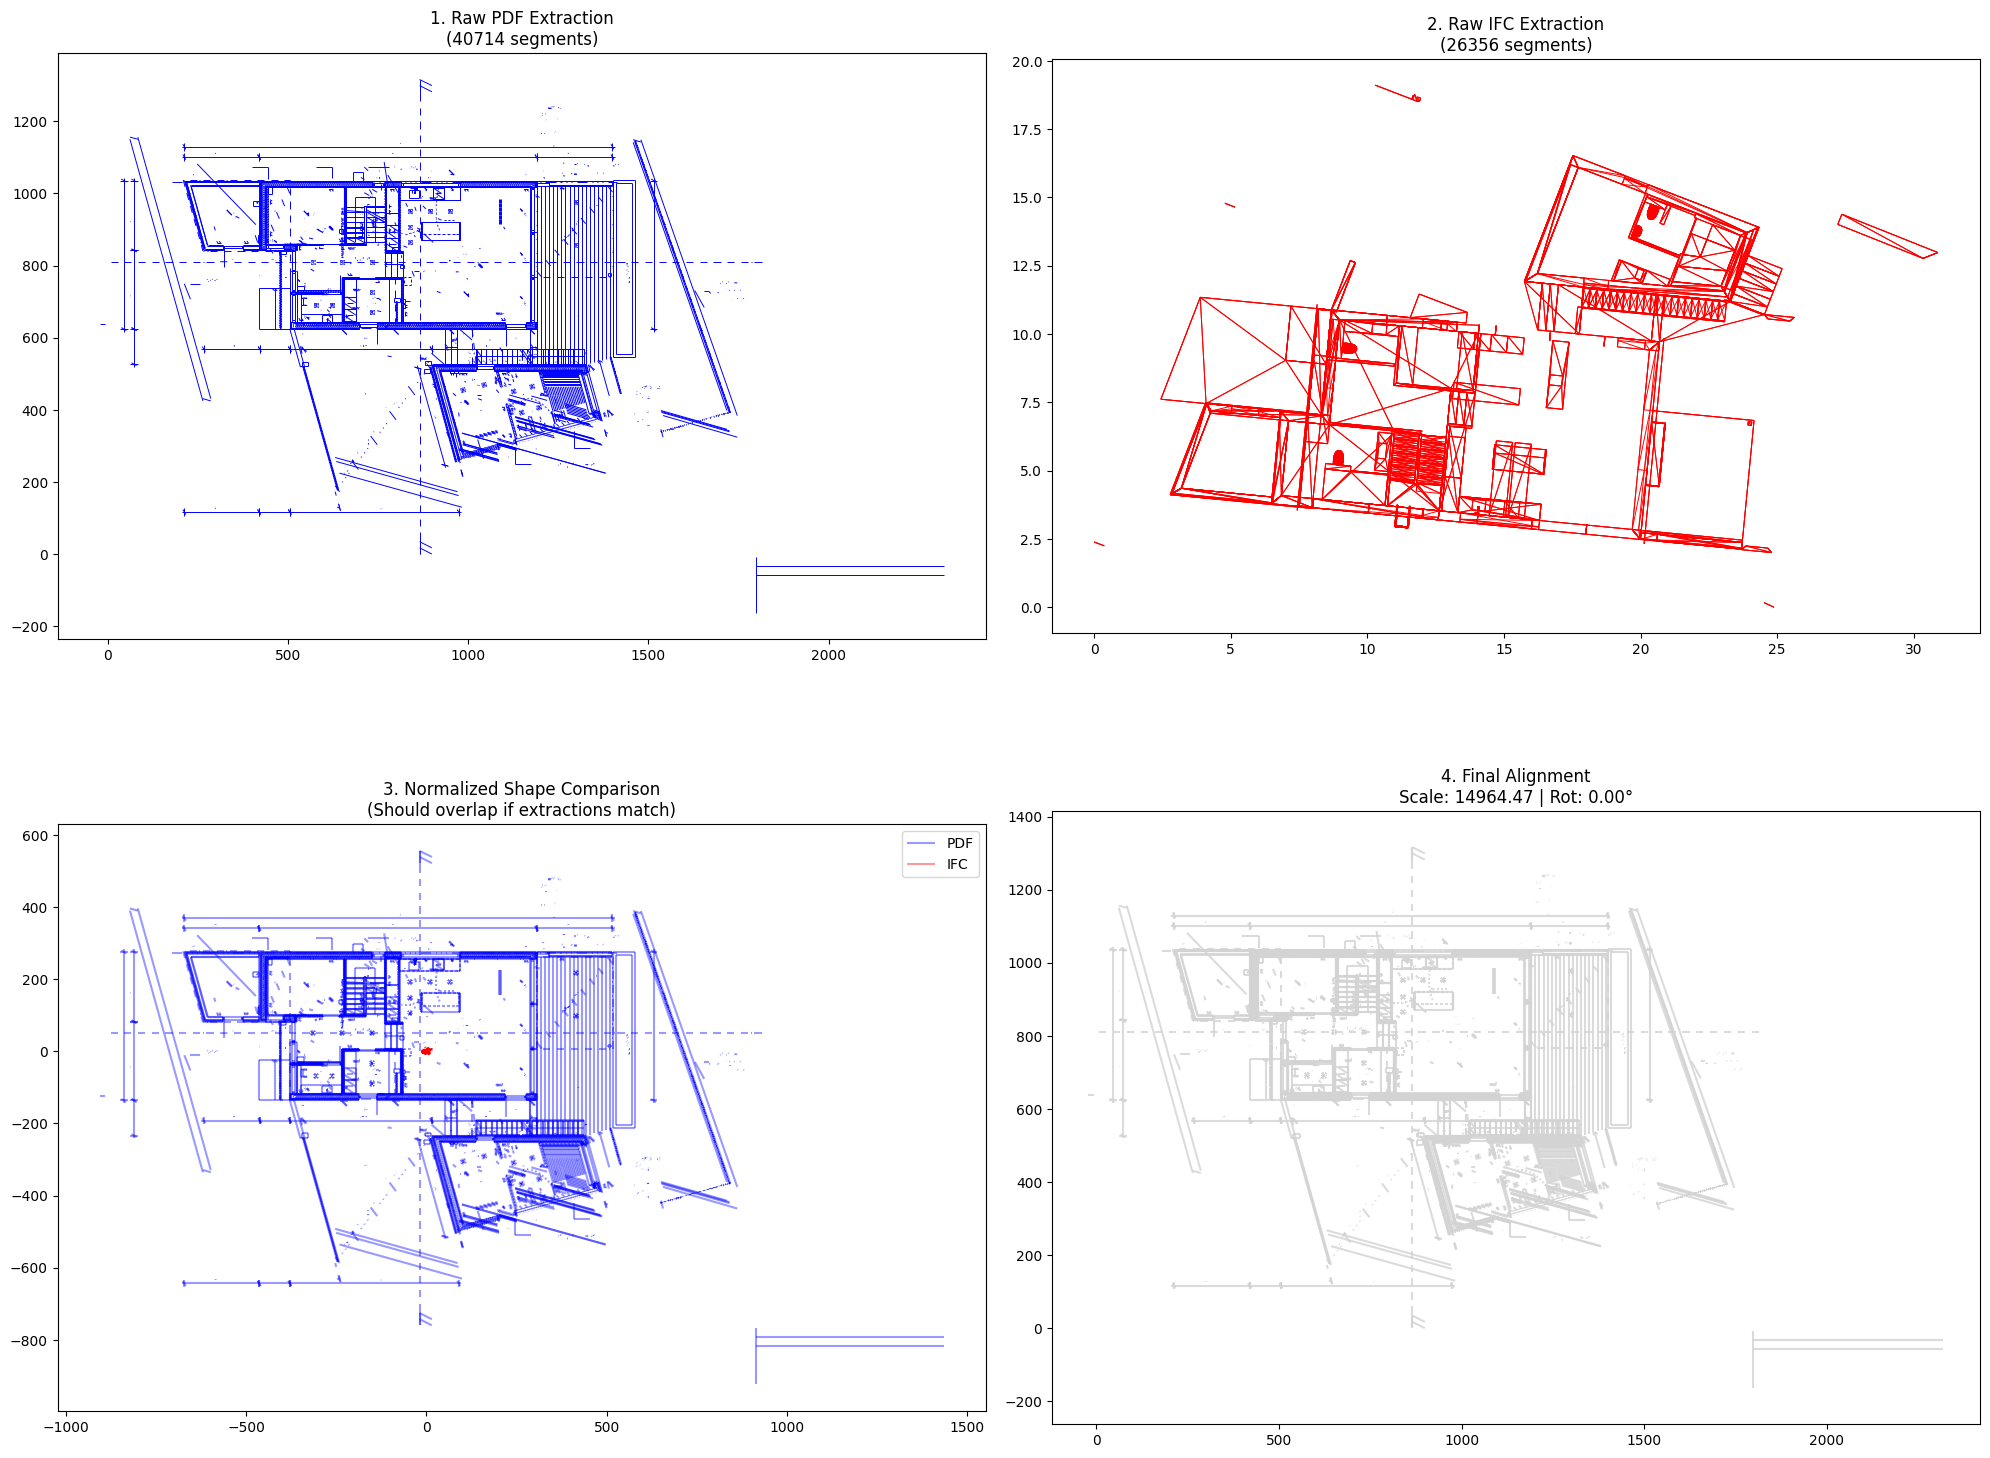

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 1. Load the data
FILE_PATH = "/home/chidepnek/RoboAI/BIM/BOMBIM/BIM2/backend/src/reg_v2/alignment_debug.pkl"
with open(FILE_PATH, "rb") as f:
    data = pickle.load(f)

pdf_segs = data["pdf_segs"]
ifc_segs = data["ifc_segs"]
s, theta, tx, ty = data["params"]
base_scale = data["base_scale"]
effective_scale = s * base_scale

# 2. Transform the IFC segments for the Overlay
rad = np.radians(theta)
R = np.array([[np.cos(rad), -np.sin(rad)], [np.sin(rad), np.cos(rad)]])
transformed_ifc = []
for x1, y1, x2, y2 in ifc_segs:
    p1 = effective_scale * (R @ np.array([x1, y1])) + np.array([tx, ty])
    p2 = effective_scale * (R @ np.array([x2, y2])) + np.array([tx, ty])
    transformed_ifc.append([(p1[0], p1[1]), (p2[0], p2[1])])

# 3. Create a 4-panel debug dashboard
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

# --- PANEL 1: RAW PDF EXTRACTION ---
pdf_raw_lc = LineCollection([[(s[0], s[1]), (s[2], s[3])] for s in pdf_segs], color='blue', linewidths=0.7)
axs[0, 0].add_collection(pdf_raw_lc)
axs[0, 0].set_title(f"1. Raw PDF Extraction\n({len(pdf_segs)} segments)")
axs[0, 0].autoscale()
axs[0, 0].set_aspect('equal')

# --- PANEL 2: RAW IFC EXTRACTION ---
ifc_raw_lc = LineCollection([[(s[0], s[1]), (s[2], s[3])] for s in ifc_segs], color='red', linewidths=0.7)
axs[0, 1].add_collection(ifc_raw_lc)
axs[0, 1].set_title(f"2. Raw IFC Extraction\n({len(ifc_segs)} segments)")
axs[0, 1].autoscale()
axs[0, 1].set_aspect('equal')

# --- PANEL 3: NORMALIZED OVERLAP (SHAPE CHECK) ---
def get_norm(segments):
    pts = np.array([[(s[0], s[1]), (s[2], s[3])] for s in segments]).reshape(-1, 2)
    center = np.mean(pts, axis=0)
    return [[((s[0]-center[0]), (s[1]-center[1])), ((s[2]-center[0]), (s[3]-center[1]))] for s in segments]

axs[1, 0].add_collection(LineCollection(get_norm(pdf_segs), color='blue', alpha=0.4, label='PDF'))
axs[1, 0].add_collection(LineCollection(get_norm(ifc_segs), color='red', alpha=0.4, label='IFC'))
axs[1, 0].set_title("3. Normalized Shape Comparison\n(Should overlap if extractions match)")
axs[1, 0].autoscale()
axs[1, 0].set_aspect('equal')
axs[1, 0].legend()

# --- PANEL 4: FINAL ALIGNMENT OVERLAY ---
axs[1, 1].add_collection(LineCollection([[(s[0], s[1]), (s[2], s[3])] for s in pdf_segs], color='lightgray', alpha=0.8))
axs[1, 1].add_collection(LineCollection(transformed_ifc, color='red', linewidths=1.2))
axs[1, 1].set_title(f"4. Final Alignment\nScale: {effective_scale:.2f} | Rot: {theta:.2f}°")

# Zoom on the house area for the final result
pdf_pts = np.array([[(s[0], s[1]), (s[2], s[3])] for s in pdf_segs]).reshape(-1, 2)
p_min, p_max = np.min(pdf_pts, axis=0), np.max(pdf_pts, axis=0)
axs[1, 1].set_xlim(p_min[0]-100, p_max[0]+100)
axs[1, 1].set_ylim(p_min[1]-100, p_max[1]+100)
axs[1, 1].set_aspect('equal')

plt.tight_layout()
plt.show()

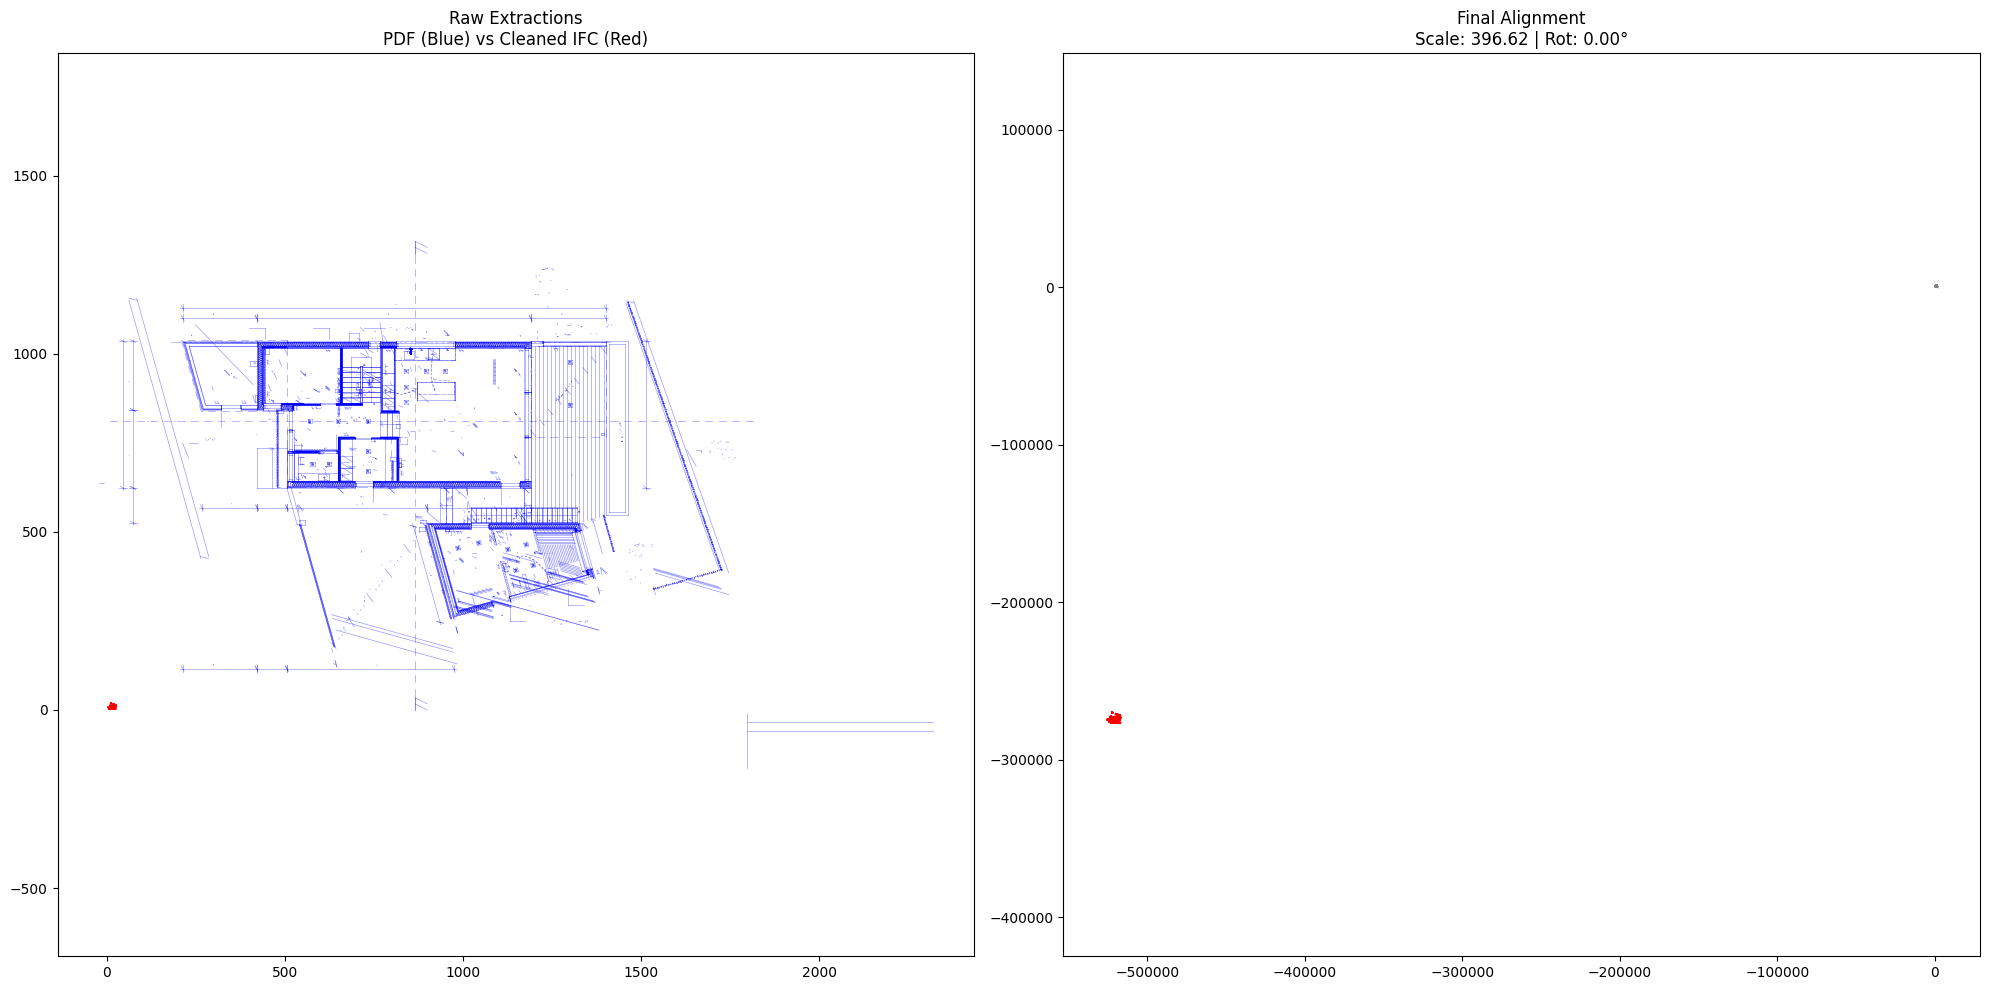

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
with open("/home/chidepnek/RoboAI/BIM/BOMBIM/BIM2/backend/src/reg_v2/alignment_debug.pkl", "rb") as f:
    debug_data = pickle.load(f)# Adjust to pickle.load(f) if using actual file

params = debug_data['params']
base_scale = debug_data['base_scale']
pdf_segs = debug_data['pdf_segs']
ifc_segs = debug_data['ifc_segs']

def transform_segments_final(segments, params, auto_scale):
    s_opt, theta, tx, ty = params
    full_scale = s_opt * auto_scale
    rad = np.radians(theta)
    cos_t, sin_t = np.cos(rad), np.sin(rad)
    
    # We must normalize the raw IFC to (0,0) here as well 
    # to match what the optimizer saw
    pts = np.array([[s[0], s[1], s[2], s[3]] for s in segments])
    mx, my = np.min(pts[:, [0, 2]]), np.min(pts[:, [1, 3]])

    transformed = []
    for x1, y1, x2, y2 in segments:
        # 1. Zero out the raw coordinates first
        x1, y1 = x1 - mx, y1 - my
        x2, y2 = x2 - mx, y2 - my
        
        # 2. Scale and Rotate
        nx1 = (x1 * cos_t - y1 * sin_t) * full_scale + tx
        ny1 = (x1 * sin_t + y1 * cos_t) * full_scale + ty
        nx2 = (x2 * cos_t - y2 * sin_t) * full_scale + tx
        ny2 = (x2 * sin_t + y2 * cos_t) * full_scale + ty
        
        transformed.append((nx1, ny1, nx2, ny2))
    return transformed

# 2. APPLY TRANSFORM
aligned_ifc = transform_segments_final(ifc_segs, params, base_scale)

# 3. CREATE PLOT
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# --- PANEL 1: RAW EXTRACTION (Verification) ---
# Shows the cleaned IFC (red) and PDF (blue) in their own units
for s in pdf_segs:
    axes[0].plot([s[0], s[2]], [s[1], s[3]], color='blue', alpha=0.4, lw=0.5)
for s in ifc_segs:
    axes[0].plot([s[0], s[2]], [s[1], s[3]], color='red', alpha=0.8, lw=1)
axes[0].set_title(f"Raw Extractions\nPDF (Blue) vs Cleaned IFC (Red)")
axes[0].axis('equal')

# --- PANEL 2: FINAL ALIGNMENT OVERLAY ---
# Plots the PDF in light gray and the transformed IFC in bright red
for s in pdf_segs:
    axes[1].plot([s[0], s[2]], [s[1], s[3]], color='gray', alpha=0.3, lw=0.8)

for s in aligned_ifc:
    axes[1].plot([s[0], s[2]], [s[1], s[3]], color='red', alpha=1.0, lw=1.2)

s_val, r_val, tx_val, ty_val = params
axes[1].set_title(f"Final Alignment\nScale: {s_val * base_scale:.2f} | Rot: {r_val:.2f}°")
axes[1].axis('equal')

plt.tight_layout()
plt.show()